### **IMPORT LIBRARY**

In [ ]:
import os
import copy
import hashlib
import time

from google.colab import files

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

### **CLONE DATASET DARI GITHUB**

In [ ]:
!git clone https://github.com/Evameivina/skindisease

Cloning into 'skindisease'...
remote: Enumerating objects: 31223, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 31223 (delta 112), reused 3 (delta 3), pack-reused 31040 (from 2)
Receiving objects: 100% (31223/31223), 739.14 MiB | 20.01 MiB/s, done.
Resolving deltas: 100% (272/272), done.
Updating files: 100% (30320/30320), done.


### **DATA UNDERSTANDING**

In [ ]:
data_dir = "skindisease/Dataset_Klasifikasi"

classes_dir = sorted([c for c in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, c))])

df_info = pd.DataFrame({
    "Class": classes_dir,
    "Total Images": [len(os.listdir(os.path.join(data_dir, c))) for c in classes_dir]
})

classes = df_info['Class'].values

print(f"Jumlah Kelas : {len(df_info)}")
print(f"Total Gambar : {df_info['Total Images'].sum()}\n")

display(df_info)

Jumlah Kelas : 4
Total Gambar : 30260



,Class,Total Images
0,ECZEMA,6715
1,HERPES ZOSTER,8082
2,NORMAL,7334
3,RINGWORM,8129


### **EXPLORATORY DATA ANALYSIS**

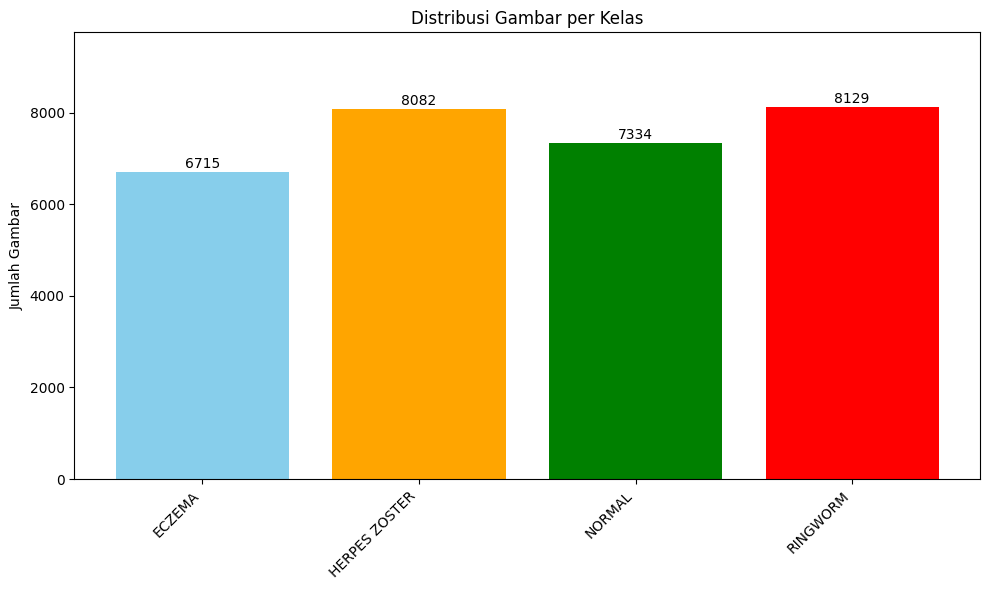

In [ ]:
classes = df_info['Class'].values
counts = df_info['Total Images'].values

plt.figure(figsize=(10,6))

bars = plt.bar(classes, counts, color=['skyblue','orange','green','red'])

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=10)

plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Gambar per Kelas')

plt.ylim(0, max(counts) * 1.2)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

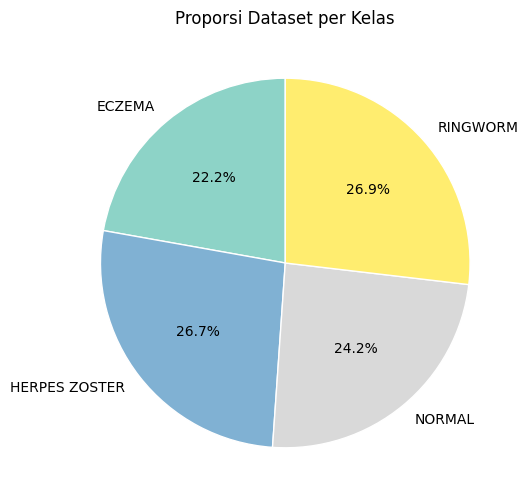

In [ ]:
class_counts = df_info.set_index('Class')['Total Images']

plt.figure(figsize=(6,6))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3(np.linspace(0, 1, len(class_counts))),
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Proporsi Dataset per Kelas")
plt.show()

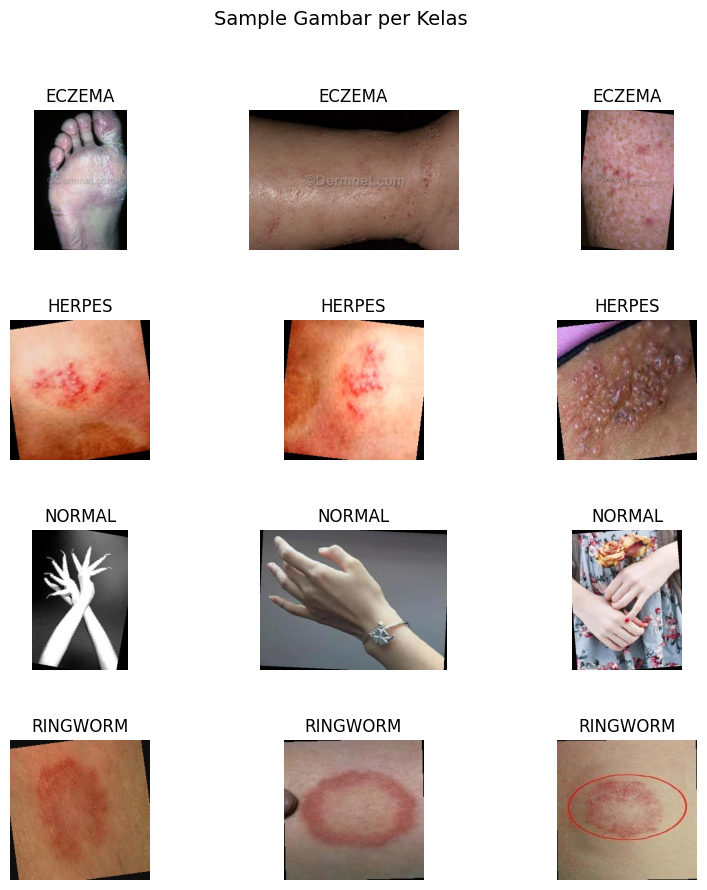

In [ ]:
df_images = pd.DataFrame([
    {
        'filepath': os.path.join(data_dir, c, img),
        'Class': c
    }
    for c in classes_dir
    for img in os.listdir(os.path.join(data_dir, c))
])

plt.figure(figsize=(10,10))

for i, cls in enumerate(classes):
    class_df = df_images[df_images['Class'] == cls]

    if not class_df.empty:
        samples = class_df.sample(min(3, len(class_df)), random_state=42)

        for j, (_, row) in enumerate(samples.iterrows()):
            plt.subplot(len(classes), 3, i*3 + j + 1)

            img = Image.open(row['filepath']).convert('RGB')
            plt.imshow(img)

            plt.title(cls.split()[0])
            plt.axis('off')

plt.suptitle("Sample Gambar per Kelas", fontsize=14)
plt.subplots_adjust(hspace=0.5)
plt.show()

### **DATA PREPROCESSING & DATA SPLITTING**



In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

In [ ]:
data_dir = "skindisease/Dataset_Klasifikasi"
full_dataset = datasets.ImageFolder(root=data_dir)
all_paths = [p for p, _ in full_dataset.samples]
all_labels = [l for _, l in full_dataset.samples]

In [ ]:
valid_paths, valid_labels = [], []

for p, l in zip(all_paths, all_labels):
    if cv2.imread(p) is not None:
        valid_paths.append(p)
        valid_labels.append(l)

all_paths, all_labels = valid_paths, valid_labels
print("After removing broken images:", len(all_paths))

After removing broken images: 30260


In [ ]:
def hash_image(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

seen = set()
unique_paths, unique_labels = [], []

for p, l in zip(all_paths, all_labels):
    h = hash_image(p)
    if h and h not in seen:
        seen.add(h)
        unique_paths.append(p)
        unique_labels.append(l)

all_paths, all_labels = unique_paths, unique_labels
print("After removing duplicates:", len(all_paths))

After removing duplicates: 30151


In [ ]:
# 10% test
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.1,
    stratify=all_labels,
    random_state=SEED
)

# 70% train, 20% val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels,
    test_size=0.2222,
    stratify=trainval_labels,
    random_state=SEED
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Train: 21105
Val: 6030
Test: 3016


In [ ]:
# CHECK DATA LEAKAGE
def get_hash_set(paths):
    hashes = set()
    for p in paths:
        h = hash_image(p)
        if h:
            hashes.add(h)
    return hashes

train_hash = get_hash_set(train_paths)
val_hash   = get_hash_set(val_paths)
test_hash  = get_hash_set(test_paths)

# Cek overlap
train_val_overlap  = train_hash.intersection(val_hash)
train_test_overlap = train_hash.intersection(test_hash)
val_test_overlap   = val_hash.intersection(test_hash)

print("DATA LEAKAGE CHECK")
print(f"Train-Val Overlap  : {len(train_val_overlap)}")
print(f"Train-Test Overlap : {len(train_test_overlap)}")
print(f"Val-Test Overlap   : {len(val_test_overlap)}")

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("Tidak ada data leakage")
else:
    print("Ada data yang overlap!")

DATA LEAKAGE CHECK
Train-Val Overlap  : 0
Train-Test Overlap : 0
Val-Test Overlap   : 0
Tidak ada data leakage


### **DATA PREPARATION**

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3,0.3),
    transforms.RandomAutocontrast(p=0.4),
    transforms.RandomPerspective(0.4, p=0.5),
    transforms.RandomAdjustSharpness(2, p=0.4),
    transforms.GaussianBlur(3, sigma=(0.1, 2.5)),
    transforms.RandomGrayscale(0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
class SkinDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE))

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

In [ ]:
train_dataset = SkinDataset(train_paths, train_labels, train_transform)
val_dataset   = SkinDataset(val_paths, val_labels, val_test_transform)
test_dataset  = SkinDataset(test_paths, test_labels, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

### **MODEL 3 - CONVNEXT_TINY**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

classes = full_dataset.classes
NUM_CLASSES = len(classes)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {classes}")

# Stage 1
EPOCHS_S1 = 10
LR_S1 = 1e-5
PATIENCE_S1 = 3

# Stage 2
EPOCHS_S2 = 10
LR_S2 = 1e-6
WEIGHT_DECAY_S2 = 1e-4
PATIENCE_S2 = 3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Using device: cuda
Number of classes: 4
Classes: ['ECZEMA', 'HERPES ZOSTER', 'NORMAL', 'RINGWORM']


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, patience):

    best_acc = 0
    best_wts = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    no_improve = 0

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        train_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                loss = criterion(out, y)

                val_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"Time: {(time.time() - start_time):.2f}s")

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_wts)
    return model, history, best_acc

In [ ]:
convnext = models.convnext_tiny(weights='IMAGENET1K_V1')

in_features = convnext.classifier[2].in_features

convnext.classifier = nn.Sequential(
    nn.Flatten(),
    nn.LayerNorm(in_features),
    nn.Linear(in_features, 256),
    nn.GELU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

convnext = convnext.to(device)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 177MB/s]


### **STAGE 1 CLASSIFIER**

In [ ]:
print(">>> STAGE 1: WARM-UP CLASSIFIER <<<")

for p in convnext.features.parameters():
    p.requires_grad = False

optimizer_s1 = optim.Adam(
    convnext.classifier.parameters(),
    lr=LR_S1
)

scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s1,
    mode='min',
    factor=0.5,
    patience=2
)

convnext, history1, acc1 = train_model(
    convnext,
    train_loader,
    val_loader,
    criterion,
    optimizer_s1,
    scheduler_s1,
    EPOCHS_S1,
    PATIENCE_S1
)

>>> STAGE 1: WARM-UP CLASSIFIER <<<
Epoch 1/10 | Train Loss: 1.0808 Acc: 0.6482 | Val Loss: 0.7534 Acc: 0.8776 | Time: 282.16s
Epoch 2/10 | Train Loss: 0.6902 Acc: 0.8785 | Val Loss: 0.5648 Acc: 0.9244 | Time: 270.97s
Epoch 3/10 | Train Loss: 0.5797 Acc: 0.9137 | Val Loss: 0.5110 Acc: 0.9486 | Time: 275.14s
Epoch 4/10 | Train Loss: 0.5380 Acc: 0.9317 | Val Loss: 0.4839 Acc: 0.9602 | Time: 271.01s
Epoch 5/10 | Train Loss: 0.5163 Acc: 0.9414 | Val Loss: 0.4669 Acc: 0.9697 | Time: 267.88s
Epoch 6/10 | Train Loss: 0.5006 Acc: 0.9518 | Val Loss: 0.4543 Acc: 0.9784 | Time: 267.06s
Epoch 7/10 | Train Loss: 0.4865 Acc: 0.9572 | Val Loss: 0.4463 Acc: 0.9813 | Time: 267.36s
Epoch 8/10 | Train Loss: 0.4791 Acc: 0.9611 | Val Loss: 0.4374 Acc: 0.9834 | Time: 277.88s
Epoch 9/10 | Train Loss: 0.4684 Acc: 0.9686 | Val Loss: 0.4312 Acc: 0.9856 | Time: 270.19s
Epoch 10/10 | Train Loss: 0.4630 Acc: 0.9707 | Val Loss: 0.4277 Acc: 0.9867 | Time: 269.82s


### **STAGE 2 FINE TUNING**

In [ ]:
print("\n>>> STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<")

for name, param in convnext.named_parameters():
    if "features.6" in name or "features.7" in name:
        param.requires_grad = True

optimizer_s2 = optim.Adam([
    {
        'params': [p for name, p in convnext.named_parameters()
                   if ("features.6" in name or "features.7" in name) and p.requires_grad],
        'lr': LR_S2 / 10
    },
    {
        'params': [p for p in convnext.classifier.parameters() if p.requires_grad],
        'lr': LR_S2
    }
], weight_decay=WEIGHT_DECAY_S2)

scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s2,
    mode='min',
    factor=0.2,
    patience=2
)

convnext, history2, acc2 = train_model(
    convnext,
    train_loader,
    val_loader,
    criterion,
    optimizer_s2,
    scheduler_s2,
    epochs=EPOCHS_S2,
    patience=PATIENCE_S2
)


>>> STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<
Epoch 1/10 | Train Loss: 0.4585 Acc: 0.9728 | Val Loss: 0.4251 Acc: 0.9879 | Time: 281.15s
Epoch 2/10 | Train Loss: 0.4575 Acc: 0.9722 | Val Loss: 0.4235 Acc: 0.9884 | Time: 284.48s
Epoch 3/10 | Train Loss: 0.4552 Acc: 0.9736 | Val Loss: 0.4221 Acc: 0.9891 | Time: 281.41s
Epoch 4/10 | Train Loss: 0.4523 Acc: 0.9742 | Val Loss: 0.4204 Acc: 0.9892 | Time: 284.60s
Epoch 5/10 | Train Loss: 0.4498 Acc: 0.9773 | Val Loss: 0.4190 Acc: 0.9897 | Time: 282.08s
Epoch 6/10 | Train Loss: 0.4493 Acc: 0.9781 | Val Loss: 0.4176 Acc: 0.9897 | Time: 284.86s
Epoch 7/10 | Train Loss: 0.4489 Acc: 0.9773 | Val Loss: 0.4164 Acc: 0.9899 | Time: 283.43s
Epoch 8/10 | Train Loss: 0.4468 Acc: 0.9774 | Val Loss: 0.4151 Acc: 0.9904 | Time: 281.83s
Epoch 9/10 | Train Loss: 0.4448 Acc: 0.9784 | Val Loss: 0.4135 Acc: 0.9907 | Time: 278.07s
Epoch 10/10 | Train Loss: 0.4437 Acc: 0.9788 | Val Loss: 0.4122 Acc: 0.9909 | Time: 279.69s


In [ ]:
!pip install torchinfo
from torchinfo import summary
summary(convnext, input_size=(1, 3, 224, 224), device=device)

Layer (type:depth-idx)                        Output Shape              Param #
ConvNeXt                                      [1, 4]                    --
├─Sequential: 1-1                             [1, 768, 7, 7]            --
│    └─Conv2dNormActivation: 2-1              [1, 96, 56, 56]           --
│    │    └─Conv2d: 3-1                       [1, 96, 56, 56]           (4,704)
│    │    └─LayerNorm2d: 3-2                  [1, 96, 56, 56]           (192)
│    └─Sequential: 2-2                        [1, 96, 56, 56]           --
│    │    └─CNBlock: 3-3                      [1, 96, 56, 56]           (79,296)
│    │    └─CNBlock: 3-4                      [1, 96, 56, 56]           (79,296)
│    │    └─CNBlock: 3-5                      [1, 96, 56, 56]           (79,296)
│    └─Sequential: 2-3                        [1, 192, 28, 28]          --
│    │    └─LayerNorm2d: 3-6                  [1, 96, 56, 56]           (192)
│    │    └─Conv2d: 3-7                       [1, 192, 28, 28]    

### **EVALUATION**


In [ ]:
print("\n" + "="*65)
print("  >>> EVALUATION (TEST SET) <<<")
print("="*65)

convnext.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = convnext(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

correct = sum(p == t for p, t in zip(all_preds, all_targets))
test_acc = correct / len(all_targets) * 100
print(f"Test Accuracy: {test_acc:.2f}%")


  >>> EVALUATION (TEST SET) <<<
Test Accuracy: 99.57%


In [ ]:
# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(all_targets, all_preds, target_names=classes))


CLASSIFICATION REPORT
               precision    recall  f1-score   support

       ECZEMA       0.99      0.99      0.99       661
HERPES ZOSTER       1.00      1.00      1.00       808
       NORMAL       1.00      1.00      1.00       734
     RINGWORM       1.00      0.99      0.99       813

     accuracy                           1.00      3016
    macro avg       1.00      1.00      1.00      3016
 weighted avg       1.00      1.00      1.00      3016



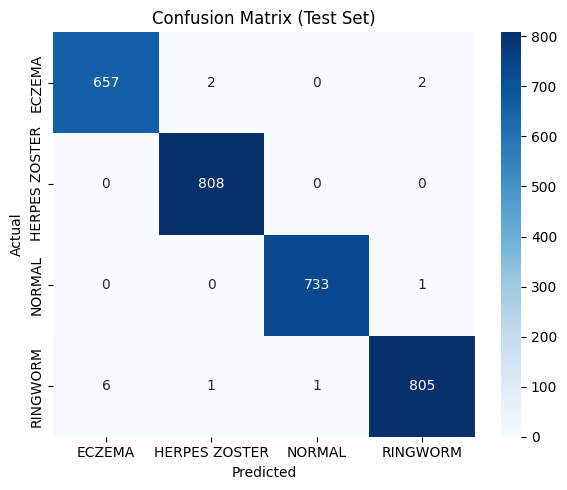

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
# Akurasi per kelas
print("AKURASI PER KELAS")
class_acc = cm.diagonal() / cm.sum(axis=1)
for cls, acc in zip(classes, class_acc):
    print(f"  {cls:<15} : {acc*100:.2f}%")

AKURASI PER KELAS
  ECZEMA          : 99.39%
  HERPES ZOSTER   : 100.00%
  NORMAL          : 99.86%
  RINGWORM        : 99.02%


In [ ]:
print("\n" + "="*65)
print("  >>> MODEL COMPARISON <<<")
print("="*65)
print(f"  Stage 1 Best Val Accuracy : {acc1:.4f}")
print(f"  Stage 2 Best Val Accuracy : {acc2:.4f}")
print(f"  Stage 1                   : {len(history1['train_loss'])} epochs")
print(f"  Stage 2                   : {len(history2['train_loss'])} epochs")
print(f"  Total                     : {len(history1['train_loss']) + len(history2['train_loss'])} epochs")


  >>> MODEL COMPARISON <<<
  Stage 1 Best Val Accuracy : 0.9867
  Stage 2 Best Val Accuracy : 0.9909
  Stage 1                   : 10 epochs
  Stage 2                   : 10 epochs
  Total                     : 20 epochs


### **MODEL SAVING**

In [ ]:
FINAL_MODEL_PATH = "convnext_skin_disease_finetuned.pth"

torch.save({
    'model_state_dict': convnext.state_dict(),
    'classes': classes,
    'stage1_acc': acc1,
    'stage2_acc': acc2
}, FINAL_MODEL_PATH)

print(f"Model fine-tuned disimpan di: {FINAL_MODEL_PATH}")

Model fine-tuned disimpan di: convnext_skin_disease_finetuned.pth


### **CROSS VALIDATION**

In [ ]:
k_folds = 3
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(trainval_paths, trainval_labels)):

    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} / {k_folds} <<<")
    print("="*65)

    train_paths_fold  = [trainval_paths[i] for i in train_idx]
    val_paths_fold    = [trainval_paths[i] for i in val_idx]
    train_labels_fold = [trainval_labels[i] for i in train_idx]
    val_labels_fold   = [trainval_labels[i] for i in val_idx]

    fold_train_dataset = SkinDataset(train_paths_fold, train_labels_fold, train_transform)
    fold_val_dataset   = SkinDataset(val_paths_fold, val_labels_fold, val_test_transform)

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    fold_val_loader = DataLoader(
        fold_val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    print(f"  Train size : {len(fold_train_dataset)} | Val size : {len(fold_val_dataset)}")

    model_cv = models.convnext_tiny(weights='IMAGENET1K_V1')
    in_features = model_cv.classifier[2].in_features
    model_cv.classifier = nn.Sequential(
        nn.Flatten(),
        nn.LayerNorm(in_features),
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(0.5),
        nn.Linear(256, NUM_CLASSES)
    )
    model_cv = model_cv.to(device)

    # Stage 1
    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} | STAGE 1: WARM-UP CLASSIFIER <<<")
    print("="*65)

    for p in model_cv.features.parameters():
        p.requires_grad = False

    optimizer_s1 = optim.Adam(
        model_cv.classifier.parameters(),
        lr=LR_S1
    )

    scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s1,
        mode='min',
        factor=0.5,
        patience=2
    )

    model_cv, _, _ = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_s1,
        scheduler_s1,
        epochs=5,
        patience=2
    )

    # Stage 2
    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} | STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<")
    print("="*65)

    for name, param in model_cv.named_parameters():
        if "features.6" in name or "features.7" in name:
            param.requires_grad = True

    optimizer_s2 = optim.Adam([
        {
            'params': [p for name, p in model_cv.named_parameters()
                       if ("features.6" in name or "features.7" in name) and p.requires_grad],
            'lr': LR_S2 / 10
        },
        {
            'params': [p for p in model_cv.classifier.parameters() if p.requires_grad],
            'lr': LR_S2
        }
    ], weight_decay=WEIGHT_DECAY_S2)

    scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s2,
        mode='min',
        factor=0.2,
        patience=2
    )

    model_cv, _, fold_acc = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_s2,
        scheduler_s2,
        epochs=5,
        patience=2
    )

    print("\n" + "="*65)
    print(f"  Fold {fold+1} Best Val Accuracy : {fold_acc:.4f}  ({fold_acc*100:.2f}%)")
    print("="*65)

    cv_results.append(fold_acc)


  >>> FOLD 1 / 3 <<<
  Train size : 18090 | Val size : 9045

  >>> FOLD 1 | STAGE 1: WARM-UP CLASSIFIER <<<
Epoch 1/5 | Train Loss: 1.0990 Acc: 0.6468 | Val Loss: 0.7954 Acc: 0.8973 | Time: 280.63s
Epoch 2/5 | Train Loss: 0.7222 Acc: 0.8714 | Val Loss: 0.5856 Acc: 0.9252 | Time: 259.29s
Epoch 3/5 | Train Loss: 0.5971 Acc: 0.9065 | Val Loss: 0.5224 Acc: 0.9428 | Time: 257.25s
Epoch 4/5 | Train Loss: 0.5496 Acc: 0.9260 | Val Loss: 0.4903 Acc: 0.9602 | Time: 258.81s
Epoch 5/5 | Train Loss: 0.5213 Acc: 0.9420 | Val Loss: 0.4737 Acc: 0.9707 | Time: 254.52s

  >>> FOLD 1 | STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<
Epoch 1/5 | Train Loss: 0.5107 Acc: 0.9458 | Val Loss: 0.4690 Acc: 0.9722 | Time: 264.14s
Epoch 2/5 | Train Loss: 0.5040 Acc: 0.9504 | Val Loss: 0.4652 Acc: 0.9740 | Time: 264.66s
Epoch 3/5 | Train Loss: 0.4999 Acc: 0.9515 | Val Loss: 0.4625 Acc: 0.9756 | Time: 262.33s
Epoch 4/5 | Train Loss: 0.4993 Acc: 0.9523 | Val Loss: 0.4590 Acc: 0.9770 | Time: 262.41s
Epoch 5/5 | Train

In [ ]:
# Ringkasan hasil CV
print(f"\n{'='*50}")
print(f"HASIL CROSS VALIDATION")
print(f"{'='*50}")
for i, acc in enumerate(cv_results):
    print(f"Fold {i+1} Val Accuracy: {acc:.4f}")
print(f"Mean Accuracy : {sum(cv_results)/len(cv_results):.4f}")
print(f"Std Accuracy  : {torch.std(torch.tensor(cv_results)).item():.4f}")


HASIL CROSS VALIDATION
Fold 1 Val Accuracy: 0.9792
Fold 2 Val Accuracy: 0.9756
Fold 3 Val Accuracy: 0.9769
Mean Accuracy : 0.9772
Std Accuracy  : 0.0018


### **INFERENCE DATASET (TEST)**

Saving aug_102_eczema-acute-12.jpg to aug_102_eczema-acute-12.jpg


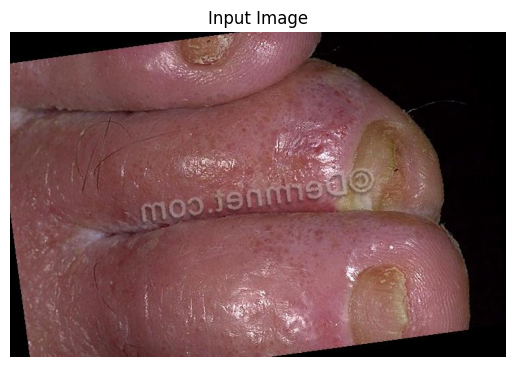

Prediksi: ECZEMA
Confidence: 0.9640782475471497


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving aug_1442_0087.jpg to aug_1442_0087.jpg


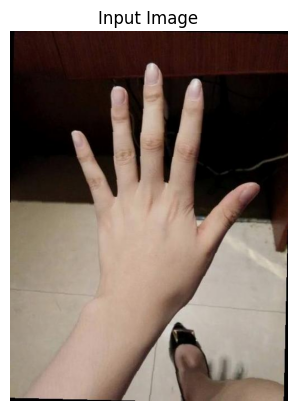

Prediksi: NORMAL
Confidence: 0.8840205669403076


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving aug_159_56_FU-ringworm (47).jpg to aug_159_56_FU-ringworm (47).jpg


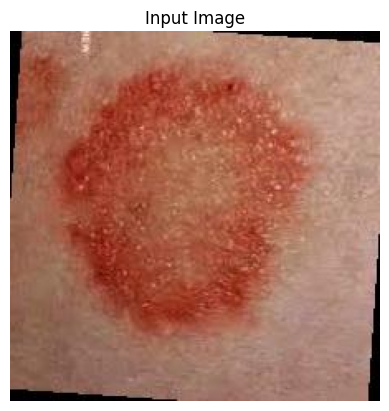

Prediksi: RINGWORM
Confidence: 0.9493675827980042


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving aug_710_45_VI-shingles (21).jpg to aug_710_45_VI-shingles (21).jpg


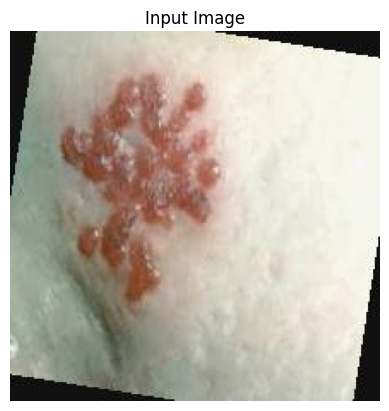

Prediksi: HERPES ZOSTER
Confidence: 0.9533329010009766


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

### **INFERENCE DATA EKSTERNAL (GOOGLE)**


Saving eczema_google9.jpg to eczema_google9.jpg


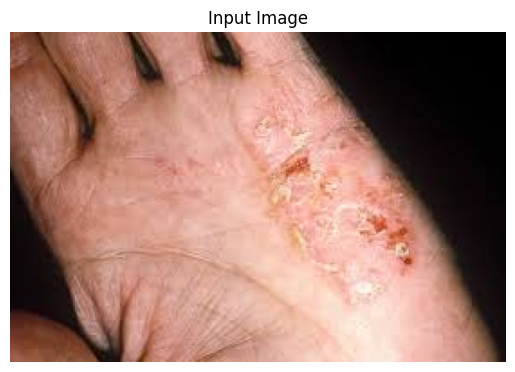

Prediksi: ECZEMA
Confidence: 0.6888214349746704


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item
    ())

Saving FU-ringworm_google5.jpg to FU-ringworm_google5.jpg


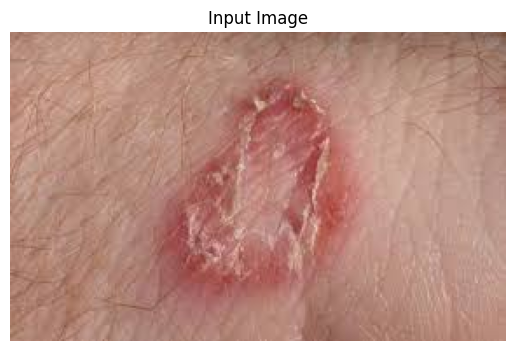

Prediksi: RINGWORM
Confidence: 0.967858076095581


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving google10.jpg to google10.jpg


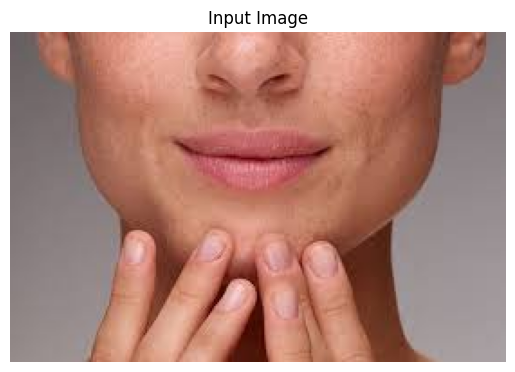

Prediksi: NORMAL
Confidence: 0.45613527297973633


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving VI_shingles_google15.jpg to VI_shingles_google15.jpg


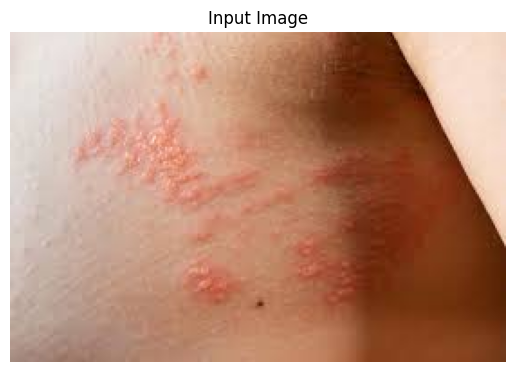

Prediksi: HERPES ZOSTER
Confidence: 0.9683692455291748


In [ ]:
uploaded = files.upload()

convnext.eval()

for img_name in uploaded.keys():

    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = convnext(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())